# Generators in python


- A generator is a function that can `return multiple times` —`one value per yield`. 
- A regular function returns once and it's done.
- A generator `returns once`, `pauses`, `remembers where it was`, and `waits for you to ask for the next one` and this cycle goes on.

**The question to ask before writing any function:**  
*"How many times does this function need to return?"*
- Once       → regular function
- Many times → generator


---

The one word that makes a ***function*** a ***generator*** is `yield`. That's it. Python sees `yield` anywhere in a function — the whole function becomes a **generator function**.  
 A generator is `lazy`, it gives you one thing at a time, and waits. **You have to ask for the next thing**. The way you ask is either `next()` or a `for` loop. And a `for` loop is just calling `next()` automatically, again and again, until there's nothing left. That's why we use `for` loop every time. It's just convenient.  



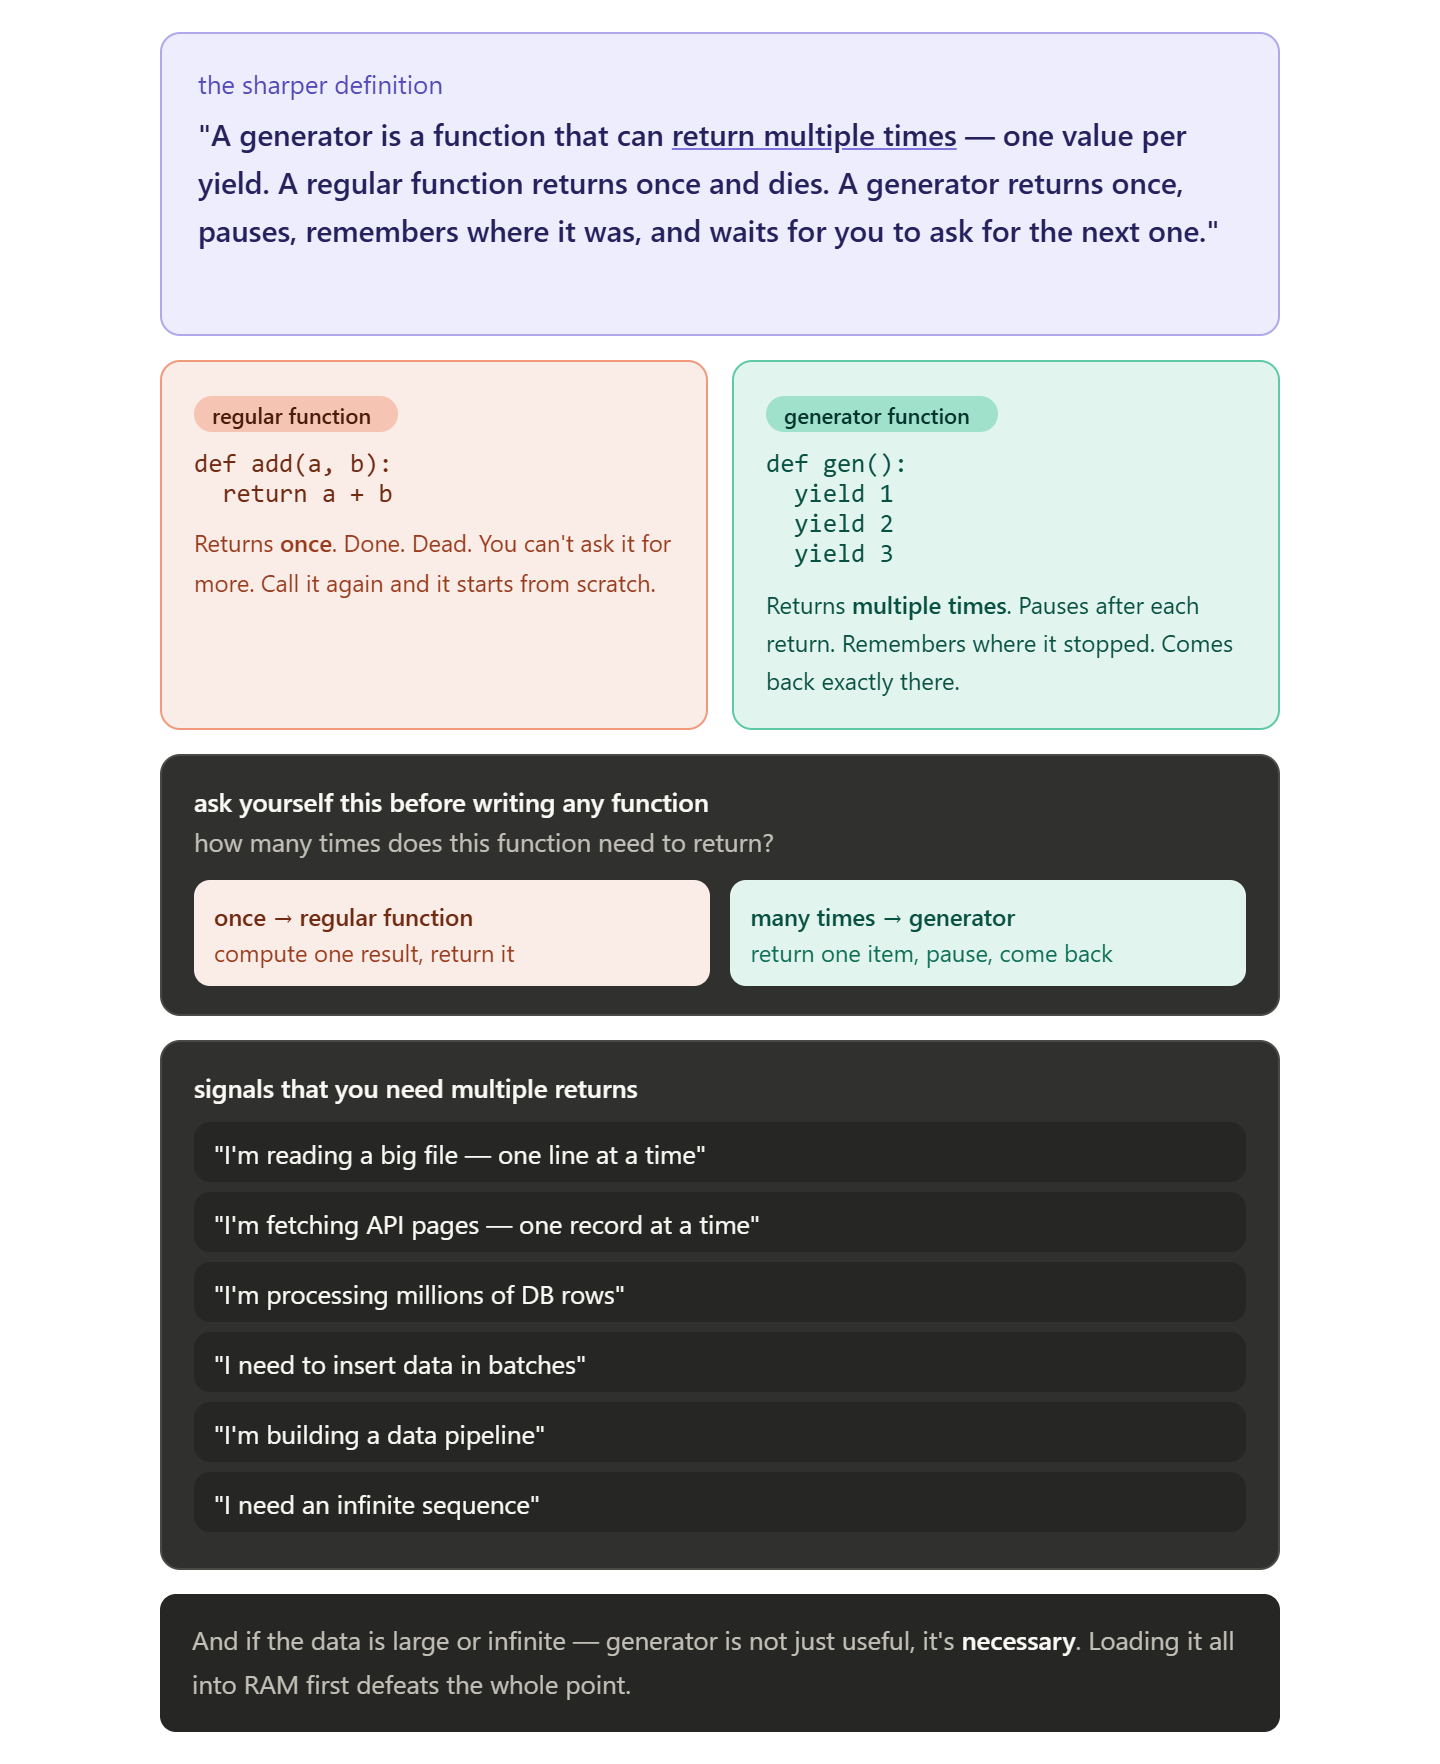

## How does it work?
- When you call a generator function, nothing runs. You just get back a generator object. Think of it like a machine that's loaded but not started.
- Then when you call `next()` — the machine starts, runs until it hits yield, gives you the value, and freezes right there. Next time you call next() — it wakes up from exactly where it froze. Not from the beginning. From where it stopped.

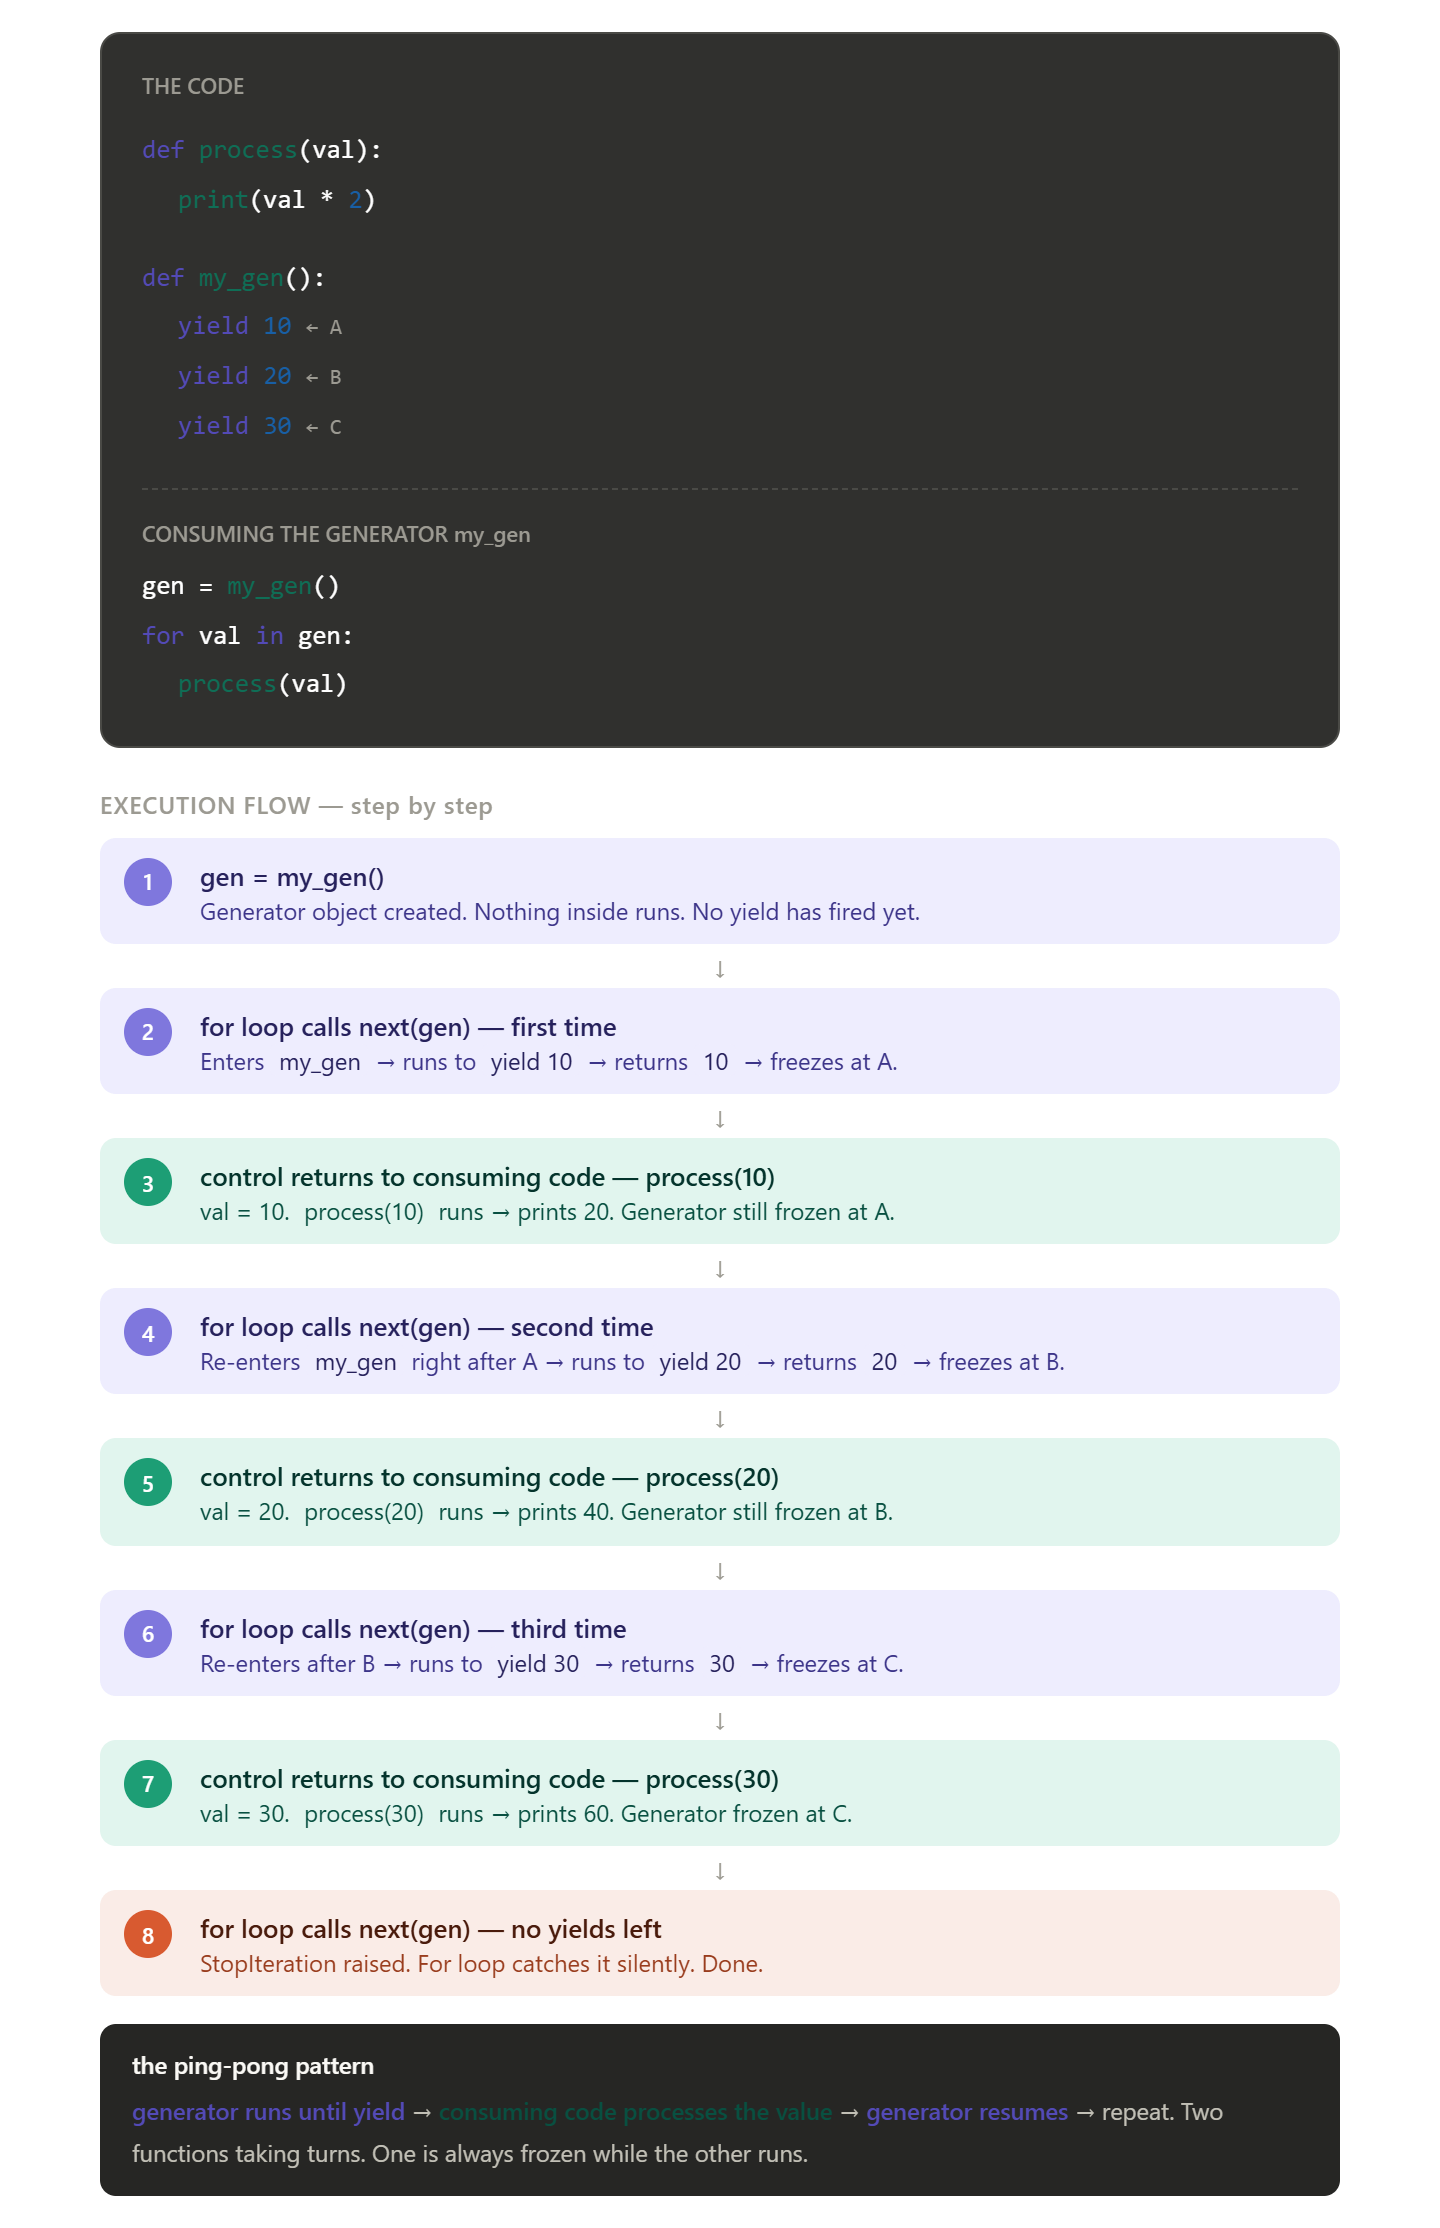

## Create and Consume concepts

### 3 ways to CREATE a 'generator':
1. **generator function**
2. **generator expression**
3. **yield from**

### 1. generator function
   ```py
    def my_gen():
        yield something   # yield makes it a generator
   ```

In [ ]:
def count_up(start, end):
    while start <= end:
        yield start
        start += 1

for n in count_up(1, 5):
    print(n) 


print("========== PRINTING USING ONLY next() ===============")
gen = count_up(1,5)
while True:
    try:
        val = next(gen)
        print(val)
    except StopIteration:
        break


## this code proves the 2 things: 1. generator can be consumed by 2 things : first: only next() and for-loop. 2. consuming through next() is not recommendable when you are expect single output only, but for set of outputs you have to call next() in loops

1
2
3
4
5
========== PRINTING USING ONLY next() ===============
1
2
3
4
5


### 2. generator expression:


In [40]:
# the pattern — just like list comprehension but with ( ) instead of [ ]
# list comprehension — builds full list NOW
squares_list = [x**2 for x in range(10)]

# generator expression — lazy, no list built
squares_gen  = (x**2 for x in range(10))

print(squares_gen)

<generator object <genexpr> at 0x00000271C9C00790>


In [41]:
# EXAMPLE:
orders = [120, 45, 300, 89, 500]

# find big orders without building a new list
big = (o for o in orders if o > 100)

for order in big:
    print(order)   # 120  300  500

120
300
500


### 3. yield from:

Example

In [42]:

def read_file(filepath):
    with open(filepath) as f:
        for line in f:
            yield line.strip()


# This generator is being created using `yield from`
def all_logs():
    yield from read_file("utility_files/jan.log")
    yield from read_file("utility_files/feb.log")
    yield from read_file("utility_files/mar.log")

for log in all_logs():
    print(log)


[jan] Server started
[jan] User logged in
[jan] Disk warning
[feb] Disk full
[feb] Server restarted
[feb] User logged out
[mar] Out of memory
[mar] Server crashed
[mar] Server recovered


## Consume generator:

A generator can only be consumed in 2 ways — `next()` and `for` loop.

1. **next()**
   - Gives one value at a time from the generator
   - Though you can call it inside a loop to get all values, that is 
     unnecessary since for loop does the same thing in fewer lines
    
    ```python
      gen = count_up(1, 5)
      first = next(gen)   # just the first item
    ```

2. **for loop**
   - Gives all values **`one by one`** until generator is exhausted
   - Calls `next()` automatically under the hood
   - Catches `StopIteration` automatically — no crash, just stops cleanly
   - Always prefer this when you want all values
    ```python
        for val in count_up(1, 5):
            process(val)
    ```


![green-divider](https://user-images.githubusercontent.com/7065401/52071924-c003ad80-2562-11e9-8297-1c6595f8a7ff.png)

# PROBLEMS on generator:

### 1. Challenge 1
Write a generator that produces these 3 names one by one:

In [43]:
def gen_func():
    yield "Alice"
    yield"Bob"
    yield"Charlie"

gen = gen_func()
print(next(gen))
print(next(gen))
print(next(gen))

Alice
Bob
Charlie


In [ ]:
def gen_func():
    yield "Alice"
    yield"Bob"
    yield"Charlie"

for value in gen_func():
    print(value)

Alice
Bob
Charlie


In [44]:
names = ["Alice","Bob","Charlie"]

def gen_func():
    for name in names:
        yield name

for value in gen_func():
    print(value)


Alice
Bob
Charlie


### Challenge 2 — build your own range()
Python has a built-in range(5) that gives 0 1 2 3 4. Your job is to build it yourself using a generator.

In [ ]:
def my_range(*args):
    if len(args) == 1:
       start, end = 0, int(args[0])
    elif len(args) == 2:
       start, end = args
    else:
        raise TypeError("my_range expects 1 or 2 arguments") 
     
    while start < end:
      yield start
      start += 1

for value in my_range(5):
    print(value)

0
1
2
3
4


: 

### Challenge 3 — even numbers only
Write a generator that yields only even numbers between a given range.

In [33]:
def my_gen(left, right):
    while left <= right:
        if left % 2 == 0:
            yield left
        
        left += 1


# gen = my_gen(1, 10)
# next(gen)

for val in my_gen(1, 10):
    print(val)

2
4
6
8
10


### Challenge 4 — Infinite counter
Problem:
Write a generator that counts up from a given start number — forever. The caller decides when to stop.

In [35]:
def infinite_count_gen(start):
    while True:
        yield start
        start += 1

for val in infinite_count_gen(1):
    if val > 10:
        break

    print(val)

1
2
3
4
5
6
7
8
9
10


### Challenge 5 — Read a large file line by line
Problem:   
You have a huge log file app.log. You can't load it all into memory. Write a generator that yields one line at a time, with whitespace stripped.

In [72]:

def read_file_gen(filepath):
    with open(filepath, "r") as f:
        for line in f:
            yield line.strip()


for line in read_file_gen("utility_files/app.log"):
    print(line)

INFO|2024-01-01|Server started
ERROR|2024-01-02|Disk full
INFO|2024-01-03|User logged in
ERROR|2024-01-04|Out of memory


In [50]:
# def batch_generator(data, chunk_size):
#     start = end = 0
#     batch_count = len(data) // chunk_size
#     # print(batch_count)

#     while batch_count:
#         batch = data[start : end+chunk_size]
#         end += chunk_size
#         start = end
#         yield batch
#         batch_count -= 1

#     yield data[start:]


def batch_generator(data, chunk_size):
    for i in range(0, len(data), chunk_size):
        yield data[i : i + chunk_size]
     

data = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

for batch in batch_generator(data, 3):
    print(batch)


[1, 2, 3]
[4, 5, 6]
[7, 8, 9]
[10]


### Challenge 7 — Fibonacci sequence
Problem:   
Fibonacci is 0 1 1 2 3 5 8 13 21... — each number is sum of previous two. Write a generator that yields Fibonacci numbers — the caller decides how many they want.

In [51]:
def fibonacci():
    first = 0
    second = 1

    yield first
    yield second

    while True:
        next = first + second
        yield next
        first = second
        second = next


gen = fibonacci()
for i in gen:
    if i > 50:
        break

    print(i)

0
1
1
2
3
5
8
13
21
34


### Challenge 8 — CSV row parser
Problem:   
You have a CSV file data.csv that looks like this:

In [71]:
def csv_parser(filepath):
    with open(filepath) as f:
        header = next(f)
        keys = header.strip().split(",")
        for line in f:
            values = line.strip().split(",")
            yield dict(zip(keys,values))

for item in csv_parser("utility_files/data.csv"):
    print(item)

{'name': 'Alice', 'age': '30', 'city': 'Mumbai'}
{'name': 'Bob', 'age': '25', 'city': 'Delhi'}
{'name': 'Charlie', 'age': '35', 'city': 'Bangalore'}


### Challenge 9 — Pipeline

This one combines everything you've learned so far.

**Problem:**
You have `app.log` where each line looks like this:
```txt
INFO|2024-01-01|Server started
ERROR|2024-01-02|Disk full
INFO|2024-01-03|User logged in
ERROR|2024-01-04|Out of memory
```

**Build a 3 step pipeline using 3 separate generators chained together:**
- step 1 — read lines from file
lines = read_lines("app.log")

- step 2 — filter only ERROR lines
errors = filter_errors(lines)

- step 3 — parse each line into a dict
parsed = parse_line(errors)

for item in parsed:
    print(item)

- output:   
{'level': 'ERROR', 'date': '2024-01-02', 'message': 'Disk full'}   
{'level': 'ERROR', 'date': '2024-01-04', 'message': 'Out of memory'}


In [77]:
from enum import Enum, StrEnum

class LogsKeys(StrEnum):
    LEVEL = "level"
    DATE = "date"
    MESSAGE = "message"

def read_file(filepath):
    with open(filepath) as f:
        for line in f:
            yield line.strip()

def filter_errors(lines):
    for line in lines:
        parts = line.split("|")
        if parts[0].lower() == "error":
            yield parts

def parse_line(errors):
    for error in errors:
        yield dict(zip([key.value for key in LogsKeys], error))


lines = read_file("utility_files/app.log")
errors = filter_errors(lines)
parsed_data = parse_line(errors)

for item in parsed_data:
    print(item)

{'level': 'ERROR', 'date': '2024-01-02', 'message': 'Disk full'}
{'level': 'ERROR', 'date': '2024-01-04', 'message': 'Out of memory'}


### Challenge 10 — Paginated API
Problem:   
Most real APIs don't give you all data at once. They give it page by page. You need to keep fetching until there are no more pages.

In [79]:

# Let's say this function is the API, and data is being received in pages.
def fake_api(page):
    data = {
        1: {"results": ["order_1", "order_2", "order_3"], "has_next": True},
        2: {"results": ["order_4", "order_5", "order_6"], "has_next": True},
        3: {"results": ["order_7", "order_8"], "has_next": False},
    }
    return data.get(page, {"results": [], "has_next": False})


def get_all_orders():

    has_next = True
    page = 1
    while has_next:
        data = fake_api(page)
        results = data.get('results', [])
        for result in results:
            yield result

        has_next = data.get("has_next")
        page += 1


gen = get_all_orders()
for order in gen:
    print(order)

order_1
order_2
order_3
order_4
order_5
order_6
order_7
order_8


### Challenge 11 — Database batch insert
Problem:  
You have 10,000 users to insert into a database. Inserting one by one is too slow. Inserting all at once crashes memory. Solution — insert in batches of N.

In [83]:
def fake_db_insert(batch):
    print(f"Inserting batch of {len(batch)} records: {batch}")

def send_users_in_batch(total_users, batch_size):
    users = [f"user_{i}" for i in range(1, total_users + 1)]
    for i in range(0, total_users, batch_size):
        yield users[i : i + batch_size]


user_batch = send_users_in_batch(22, 5)

for users in user_batch:
    fake_db_insert(users)
        

Inserting batch of 5 records: ['user_1', 'user_2', 'user_3', 'user_4', 'user_5']
Inserting batch of 5 records: ['user_6', 'user_7', 'user_8', 'user_9', 'user_10']
Inserting batch of 5 records: ['user_11', 'user_12', 'user_13', 'user_14', 'user_15']
Inserting batch of 5 records: ['user_16', 'user_17', 'user_18', 'user_19', 'user_20']
Inserting batch of 2 records: ['user_21', 'user_22']


### Challenge 13 — yield from
Quick theory first:   
`yield from` is just a shortcut for yielding everything from another iterable one by one.

Problem:  
**You have 3 separate log files — jan.log, feb.log, mar.log. Write a generator that combines all 3 into one single stream, yielding lines one by one.**

In [85]:
# def jan_logs():
#     with open("utility_files/jan.log") as f:
#         for line in f:
#             yield line.strip()

# def feb_logs():
#     with open("utility_files/feb.log") as f:
#         for line in f:
#             yield line.strip()

# def mar_logs():
#     with open("utility_files/mar.log") as f:
#         for line in f:
#             yield line.strip()

# def all_logs():
#     yield from jan_logs()
#     yield from feb_logs()
#     yield from mar_logs()


# for log in all_logs():
#     print(log)


def read_file(filepath):
    with open(filepath) as f:
        for line in f:
            yield line.strip()

def all_logs():
    yield from read_file("utility_files/jan.log")
    yield from read_file("utility_files/feb.log")
    yield from read_file("utility_files/mar.log")

for log in all_logs():
    print(log)


[jan] Server started
[jan] User logged in
[jan] Disk warning
[feb] Disk full
[feb] Server restarted
[feb] User logged out
[mar] Out of memory
[mar] Server crashed
[mar] Server recovered


### Challenge 14 — send() into a generator

In [ ]:
def sum_gen():
    send_data = 0
    while True:
        value = yield send_data
        if value is None:
            continue        # ignore None, don't crash
        send_data += value


gen = sum_gen()
next(gen)           
# next(gen)
print(gen.send(10))    # 10
print(gen.send(20))    # 30
print(gen.send(5))     # 35
print(gen.send(100))   # 135

10
30
35
135


### Challenge 15 — Full ETL Pipeline

**Problem**:
You work at a company. Every day you receive a CSV file with orders. You need to:

- **Extract** — read orders from orders.csv one by one
- **Transform** — filter only completed orders and calculate 10% tax on the price
- **Load** — insert in batches of 3 into the database

In [33]:
def fake_db_insert(batch):
    print(f"Inserting batch of {len(batch)} records: {batch}")


def load_in_batches(orders, batch_size):
    batch = []
    for order in orders:
        batch.append(order)
        if len(batch) == batch_size:
            yield batch
            batch = []
    if batch:
        yield batch       


def extract_orders(filepath):
    # read csv, yield one row as dict at a time
    # hint — you built this in problem 8!

    with open(filepath) as f:
        header = next(f).strip().split(",")
        for line in f:
            values = line.strip().split(",")
            yield dict(zip(header, values))



def filter_completed(orders):
    # yield only completed orders
    # hint — problem 9 pipeline!
    for order in orders:
        status = order.get("status")
        if status.lower() == "completed":
            yield order

def add_tax(orders):
    for order in orders:
        price = int(order.get("price"))
        order["price"] = f"{price + (price / 10):.2f}"
        yield order
        

# pipeline
orders = extract_orders("utility_files/orders.csv")
completed_orders = filter_completed(orders)
tax_added = add_tax(completed_orders)
gen = load_in_batches(tax_added,3)

for batch in gen:
    fake_db_insert(batch)


Inserting batch of 3 records: [{'id': '1', 'product': 'Laptop', 'status': 'completed', 'price': '1100.00'}, {'id': '3', 'product': 'Tablet', 'status': 'completed', 'price': '825.00'}, {'id': '5', 'product': 'Keyboard', 'status': 'completed', 'price': '110.00'}]
Inserting batch of 2 records: [{'id': '6', 'product': 'Mouse', 'status': 'completed', 'price': '220.00'}, {'id': '8', 'product': 'Webcam', 'status': 'completed', 'price': '88.00'}]
